<a href="https://colab.research.google.com/github/SOURAV143-BIT/COLORECTAL-CANCER-RISK-PREDICTION-AND-SURVIVAL-USING-MACHINE-LEARNING/blob/main/colorectal_cancer_prediction_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colorectal Cancer Risk & Survival Prediction

## Objective
The goal of this project is to predict the **survival status** of colorectal cancer patients based on their demographics, medical history, and lifestyle factors.

## Dataset Overview
The dataset contains records of **colorectal cancer patients**, with features related to risk factors, treatment, and outcomes.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features.
3. **Feature Selection**: Identify important predictors for survival.
4. **Model Training**: Train a classification model to predict survival status.
5. **Evaluation**: Assess model performance using accuracy and classification reports.

In [ ]:

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


In [ ]:

# Load the dataset
df = pd.read_csv('colorectal_cancer_prediction.csv')

# Display basic information about the dataset
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89945 entries, 0 to 89944
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               89945 non-null  int64  
 1   Age                      89945 non-null  int64  
 2   Gender                   89945 non-null  object 
 3   Race                     89945 non-null  object 
 4   Region                   89945 non-null  object 
 5   Urban_or_Rural           89945 non-null  object 
 6   Socioeconomic_Status     89945 non-null  object 
 7   Family_History           89945 non-null  object 
 8   Previous_Cancer_History  89945 non-null  object 
 9   Stage_at_Diagnosis       89945 non-null  object 
 10  Tumor_Aggressiveness     89945 non-null  object 
 11  Colonoscopy_Access       89945 non-null  object 
 12  Screening_Regularity     89945 non-null  object 
 13  Diet_Type                89945 non-null  object 
 14  BMI                   

## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

In [ ]:
df.isnull().sum()



,0
Patient_ID,0
Age,0
Gender,0
Race,0
Region,0
Urban_or_Rural,0
Socioeconomic_Status,0
Family_History,0
Previous_Cancer_History,0
Stage_at_Diagnosis,0


In [ ]:
df['Time_to_Recurrence'].fillna(df['Time_to_Recurrence'].median(), inplace=True)

/tmp/ipykernel_2495/273382123.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Time_to_Recurrence'].fillna(df['Time_to_Recurrence'].median(), inplace=True)


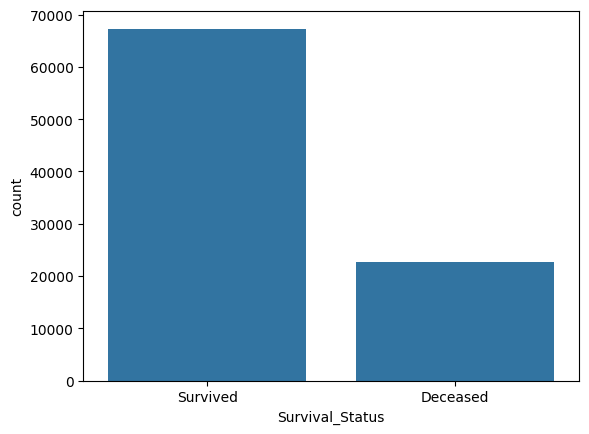

In [ ]:
# Visualize survival status distribution
sns.countplot(x='Survival_Status', data=df)
plt.show()

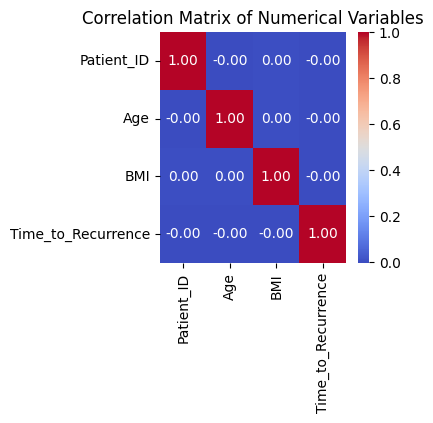

In [ ]:
# Correlation heatmap (numerical features only)


numerical_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(3, 3))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()


## Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

In [ ]:
# Drop unnecessary columns (e.g., Patient ID if present)
df.drop(['Patient_ID'], axis=1, inplace=True)

In [ ]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.columns:
  if df[col].dtype=='object':
    df[col]=le.fit_transform(df[col])


In [ ]:

# Define features and target variable
# Adjust target column name as needed

# 'df' should now have all categorical columns encoded into numerical format
x = df.drop([ 'Survival_Status'], axis=1)
y = df['Survival_Status']


In [ ]:
x

,Age,Gender,Race,Region,Urban_or_Rural,Socioeconomic_Status,Family_History,Previous_Cancer_History,Stage_at_Diagnosis,Tumor_Aggressiveness,...,Fiber_Consumption,Insurance_Coverage,Time_to_Diagnosis,Treatment_Access,Chemotherapy_Received,Radiotherapy_Received,Surgery_Received,Follow_Up_Adherence,Recurrence,Time_to_Recurrence
0,71,1,3,2,1,2,1,0,2,0,...,1,1,0,0,1,0,0,0,0,16
1,34,0,1,4,1,2,0,0,0,2,...,1,0,1,0,0,1,1,1,0,28
2,80,0,4,4,1,2,0,0,2,1,...,2,1,1,1,0,1,1,0,0,26
3,40,1,1,4,0,1,0,0,0,2,...,0,1,0,1,1,0,1,1,0,44
4,43,0,4,2,1,0,1,0,2,1,...,1,0,0,0,1,0,1,1,1,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89940,72,1,4,4,1,2,0,0,3,2,...,2,1,1,0,0,0,1,1,0,25
89941,59,0,0,4,1,1,0,0,1,1,...,0,1,0,0,0,0,1,0,0,46
89942,77,0,4,0,0,0,1,0,0,2,...,2,1,0,0,0,1,0,0,1,41
89943,37,1,3,4,0,0,0,0,1,1,...,2,1,1,1,0,0,1,0,0,47


In [ ]:
y

,Survival_Status
0,1
1,0
2,1
3,0
4,0
...,...
89940,0
89941,1
89942,1
89943,1


In [ ]:

# Split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Model Training
Train a **Logistic Regression** model to predict patient survival.

In [ ]:

# Train a Logistic Regression model
model = LogisticRegression()
model.fit(x_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Predictions

y_pred = model.predict(x_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
# Model evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7514592250819946
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      4471
           1       0.75      1.00      0.86     13518

    accuracy                           0.75     17989
   macro avg       0.38      0.50      0.43     17989
weighted avg       0.56      0.75      0.64     17989



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
